<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#permet d'aller prendre les fichiers directement dans mon drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/Colab Notebooks/

#from google.colab import files

#uploaded = files.upload()

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [ ]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(population.shape[1])
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())

3
Zone       object
Année       int64
Valeur    float64
dtype: object
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [ ]:
#Affichage les 5 premières lignes de la table
print(population.head(5))

          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [ ]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] *= 1000



In [ ]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)


In [ ]:
#Affichage les 5 premières lignes de la table pour voir les modifications
print(population.head(5))

          Zone  Année  Population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
format(dispo_alimentaire.shape[1])

'18'

In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True) #inplace=True modifie directement le dataframe
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire[['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité','Importations - Quantité','Nourriture','Pertes','Production','Semences','Traitement','Variation de stock']] *= 1000000



In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(aide_alimentaire.shape[1])

4


In [ ]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [ ]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] *= 1000

In [ ]:
#Affichage les 5 premières lignes de la table
print(aide_alimentaire.head(5))

          Zone  Année              Produit    Valeur
0  Afghanistan   2013  Autres non-céréales    682000
1  Afghanistan   2014  Autres non-céréales    335000
2  Afghanistan   2013         Blé et Farin  39224000
3  Afghanistan   2014         Blé et Farin  15160000
4  Afghanistan   2013             Céréales  40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(sous_nutrition.shape[1])

3


In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [ ]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur' : 'sous_nutrition'})


In [ ]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['sous_nutrition'] = pd.to_numeric(sous_nutrition['sous_nutrition'], errors='coerce')

#Puis remplacement des NaN en 0
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition'].fillna(0)

In [ ]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] *= 1000000


In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# On part d'une copie pour ne pas modifier l'original
sous_nutrition_copy = sous_nutrition.copy()

# On découpe l'intervalle en deux colonnes début et fin
# split va couper sur le "-" et expand va créer un dataframe a deux colonnes
# astype va assigner le type int a chacune de ses deux colonnes qui iront dans le dataframe sous_nutrition_copy dans les colonnes début et fin
sous_nutrition_copy[['debut','fin']] = sous_nutrition_copy['Année'].astype(str).str.split('-', expand=True).astype(int) # expand renvoie un dataframe, chaque partie séparée devient une colonne, une pour début une pour fin

# On remplace Année par la valeur moyenne (année de référence)
sous_nutrition_copy['Année'] = ((sous_nutrition_copy['debut'] + sous_nutrition_copy['fin']) / 2).astype(int)

# On nettoie les colonnes temporaires
sous_nutrition_copy = sous_nutrition_copy.drop(columns=['debut','fin'])

# On sélectionne pour nos 2 dataframe l'année 2017
sous_nutrition_2017 = sous_nutrition_copy[sous_nutrition_copy['Année'] == 2017]

population_2017 = population[population['Année'] == 2017]


# 7) Jointure à gauche sur sous_nutrition des deux dataframes pour l'année 2017
jointure_2017 = pd.merge(sous_nutrition_2017, population_2017, on=['Zone', 'Année'], how='right') # on joint aussi sur année car comme toute les années sont 2017 on ne veut pas importer une deuxième colonne année







In [ ]:
#Affichage du dataset
display(jointure_2017)

,Zone,Année,sous_nutrition,Population
0,Afghanistan,2017,10500000.0,36296113.0
1,Afrique du Sud,2017,3100000.0,57009756.0
2,Albanie,2017,100000.0,2884169.0
3,Algérie,2017,1300000.0,41389189.0
4,Allemagne,2017,0.0,82658409.0
...,...,...,...,...
231,Venezuela (République bolivarienne du),2017,8000000.0,29402484.0
232,Viet Nam,2017,6500000.0,94600648.0
233,Yémen,2017,0.0,27834819.0
234,Zambie,2017,0.0,16853599.0


In [ ]:
 duplicated(keep=False)#Calcul et affichage du nombre de personnes en état de sous nutrition
nb_sous_nutrition = jointure_2017['sous_nutrition'].sum()
population_globale = jointure_2017['Population'].sum()
proportion_sous_nutrition = round((nb_sous_nutrition / population_globale) * 100,0)

print("La population globale en 2017 est de : ", population_globale, "de personnes, ", proportion_sous_nutrition, "% sont en état de sous nutrition soit : ", nb_sous_nutrition, " personnes !")

La population globale en 2017 est de :  7548134111.0 de personnes,  7.0 % sont en état de sous nutrition soit :  535700000.0  personnes !


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
#Combien mange en moyenne un être humain ? Source => https://www.humanitarianlibrary.org/sites/default/files/2014/02/wfp203513.pdf?utm_source
#selon les normes onusiennes 2100 que l'on va prendre comme ref ici

In [ ]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alimentaire_population = pd.merge(dispo_alimentaire, population_2017, on='Zone', how='left')

In [ ]:
#Affichage du nouveau dataframe
dispo_alimentaire_population

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,0.0,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,2017.0,636039.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0


In [ ]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_alimentaire_population['dispo_kcal'] = dispo_alimentaire_population['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire_population['Population']
dispo_alimentaire_population

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,145184452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,...,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,2017.0,636039.0,28621755.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,6996429.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0


In [ ]:
#Calcul du nombre d'humains pouvant être nourris

# 1) On fait la somme de toute les kcal dans le monde
kcal_total = dispo_alimentaire_population["dispo_kcal"].sum()
print(kcal_total)

# 2) On divise le nb de kcal dispo par la portion minimale pour ne pas être en sous nutrition et on obtient le nombre théorique de personnes que l'on pourrait nourrir.
nb_humains_nourris = round(kcal_total / 2100,0).astype(int)
print(f"Total de personnes qui pourraient être nourries : {nb_humains_nourris}")


20918984627331.0
Total de personnes qui pourraient être nourries : 9961421251


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
#Transfert des données avec les végétaux dans un nouveau dataframe
vegetaux = dispo_alimentaire_population[dispo_alimentaire_population['Origine'] == 'vegetale']


In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
kcal_vegetaux_total = vegetaux["dispo_kcal"].sum()

In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humains_nourris_vegetaux = round(kcal_vegetaux_total / 2100,0).astype(int)
print(f"Total de personnes qui pourraient être nourries avec seulement la production végétale : {nb_humains_nourris_vegetaux}")

Total de personnes qui pourraient être nourries avec seulement la production végétale : 8219411529


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
#Calcul de la disponibilité totale
disponibilite_totale = dispo_alimentaire['Disponibilité intérieure'].sum().astype(int)
print(f"La disponibilité intérieure totale est de : {disponibilite_totale} Kg")

La disponibilité intérieure totale est de : 9848994000000 Kg


Total Aliments pour animaux : 1304245000000 Kg
Total Pertes : 453698000000 Kg
Total Nourriture : 4876258000000 Kg
Total Autres Utilisations : 865023000000 Kg
Total Semences : 154681000000 Kg
Total Traitement : 2204687000000 Kg


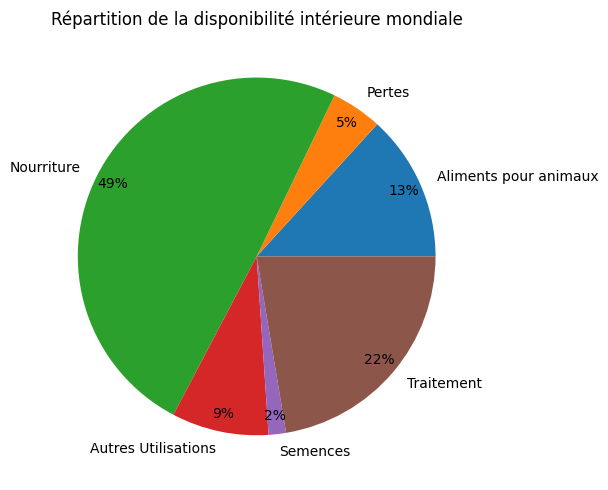

In [ ]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures (en Kg)
colonnes = ['Aliments pour animaux', 'Pertes', 'Nourriture','Autres Utilisations', 'Semences', 'Traitement']

totaux = []

for col in colonnes:
    total = dispo_alimentaire_population[col].sum().astype(int)
    totaux.append(total) #crée une liste avec les valeurs des sommes de chaque colonne
    print(f"Total {col} : {total} Kg") #f permet de faire un f-string pour afficher le texte avec les valeurs.

plt.subplots(figsize=(8,5))
plt.pie(totaux,labels=colonnes,autopct="%.0f%%",pctdistance=0.9)  # pourcentage sans décimale
plt.title("Répartition de la disponibilité intérieure mondiale")
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
#Création d'une liste avec toutes les variables

#dispo_alimentaire['Produit'].unique() pour voir toutes les infos et sélectionner que les céréales
liste_cereales = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']


In [ ]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
df_cereales = dispo_alimentaire_population[dispo_alimentaire_population['Produit'].isin(liste_cereales)] #df pour dataframe
display(df_cereales)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,...,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,2017.0,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,...,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,2017.0,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,1.300000e+07,...,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,2017.0,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,...,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,2017.0,36296113.0,9.436989e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15545,Îles Salomon,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017.0,636039.0,0.000000e+00
15568,Îles Salomon,Maïs,vegetale,0.0,0.0,1.0,0.15,0.01,0.03,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017.0,636039.0,6.360390e+05
15575,Îles Salomon,Orge,vegetale,0.0,0.0,0.0,0.07,0.00,0.01,1.000000e+06,...,1.000000e+06,0.000000e+00,0.0,0.000000e+00,0.0,1000000.0,0.0,2017.0,636039.0,0.000000e+00
15591,Îles Salomon,Riz (Eq Blanchi),vegetale,0.0,12000000.0,623.0,63.76,1.36,10.90,4.900000e+07,...,4.700000e+07,3.600000e+07,1000000.0,3.000000e+06,0.0,0.0,0.0,2017.0,636039.0,3.962523e+08


La proportion de céréales utilisées pour l'alimentation animale est de 36%


,Produit,Aliments pour animaux,Nourriture,Disponibilité intérieure,% Nourriture,% Animaux,% Autres
0,Avoine,1.625100e+10,3.903000e+09,2.340700e+10,16.67,69.43,13.90
1,Blé,1.296680e+11,4.578240e+11,6.794980e+11,67.38,19.08,13.54
2,"Céréales, Autres",1.903500e+10,5.324000e+09,2.748500e+10,19.37,69.26,11.37
3,Maïs,5.461160e+11,1.251840e+11,9.557990e+11,13.10,57.14,29.76
4,Millet,3.306000e+09,2.304000e+10,2.991100e+10,77.03,11.05,11.92
5,Orge,9.265800e+10,6.794000e+09,1.404390e+11,4.84,65.98,29.18
6,Riz (Eq Blanchi),3.359400e+10,3.772860e+11,4.756560e+11,79.32,7.06,13.62
7,Seigle,8.099000e+09,5.502000e+09,1.656700e+10,33.21,48.89,17.90
8,Sorgho,2.480800e+10,2.415300e+10,5.823700e+10,41.47,42.60,15.93


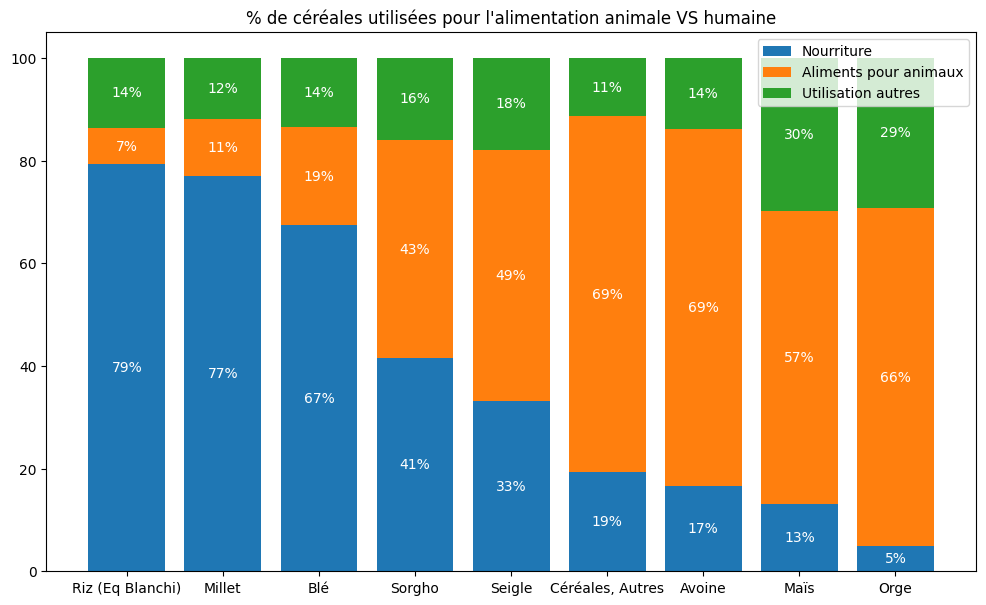

In [ ]:
#Affichage de la proportion d'alimentation animale
total_alimentation_animale = df_cereales['Aliments pour animaux'].sum()
total_dispo = df_cereales['Disponibilité intérieure'].sum()
proportion_alimentation_animale = round((total_alimentation_animale / total_dispo) * 100,0).astype(int)
print(f"La proportion de céréales utilisées pour l'alimentation animale est de {proportion_alimentation_animale}%")


#Affichage de la proportion d'alimentation animale
# 1) On aggrège en fonction des céréales afin d'avoir les totaux pour chaque céréale ce qui servira a calculer la proportion par rapport à la dispo intérieure
cols = ['Aliments pour animaux','Nourriture','Disponibilité intérieure'] #cols contient ces deux noms de colonnes pour différencier utilisé pour animaux ou alimentation humaine.
céréales_par_catégories = (df_cereales.groupby('Produit', as_index=False)[cols].sum()) #crée un dataframe qui est une aggrégation par produit  avec somme en fonctions des colonnes de cols
#as_index permet de conserver produit comme une colonne classique et non pas comme l'index pour pouvoir ensuite s'en servir dans le graph


# 2) Calcul de la proportion pour nos deux catégories
céréales_par_catégories['% Nourriture'] = round((céréales_par_catégories['Nourriture'] / céréales_par_catégories['Disponibilité intérieure']) * 100,2)
céréales_par_catégories['% Animaux'] = round((céréales_par_catégories['Aliments pour animaux'] / céréales_par_catégories['Disponibilité intérieure']) * 100,2)
céréales_par_catégories['% Autres'] = 100 - (céréales_par_catégories['% Nourriture'] + céréales_par_catégories['% Animaux'])
display(céréales_par_catégories)


# 3) Trier pour ordonner le graphique
céréales_par_catégories = céréales_par_catégories.sort_values('% Nourriture', ascending=False)

# 4) Création du graphe
plt.subplots(figsize=(12,7))

barres_nourriture = plt.bar(céréales_par_catégories['Produit'], céréales_par_catégories['% Nourriture'], label='Nourriture')#crée la barre inférieure
barres_animaux = plt.bar(céréales_par_catégories['Produit'], céréales_par_catégories['% Animaux'], bottom=céréales_par_catégories['% Nourriture'], label='Aliments pour animaux')#crée la barre supérieur en se basant avec bottom sur la barre inférieur nourriture (bottom permet d'empiler)
barres_autres = plt.bar(céréales_par_catégories['Produit'], céréales_par_catégories['% Autres'], bottom=céréales_par_catégories['% Nourriture'] + céréales_par_catégories['% Animaux'], label='Utilisation autres')

# 5) Ajouter les labels %
plt.bar_label(barres_nourriture, labels=[f"{v:.0f}%" for v in céréales_par_catégories['% Nourriture']], label_type='center', color='white') # on label ici les barres de nourritures sans chiffres après la virgules en utilisant %nourritures
plt.bar_label(barres_animaux, labels=[f"{v:.0f}%" for v in céréales_par_catégories['% Animaux']], label_type='center', color='white')
plt.bar_label(barres_autres, labels=[f"{v:.0f}%" for v in céréales_par_catégories['% Autres']], label_type='center', color='white')


plt.title("% de céréales utilisées pour l'alimentation animale VS humaine")
plt.legend()
plt.show()



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
#Création de la colonne proportion par pays
jointure_2017['proportion'] = round((jointure_2017['sous_nutrition'] / jointure_2017['Population']) * 100)

In [ ]:
#affichage après trie des 10 pires pays
pire_pays = jointure_2017.sort_values(by='proportion', ascending=False).head(10)
display(pire_pays)

,Zone,Année,sous_nutrition,Population,proportion
87,Haïti,2017,5300000.0,10982366.0,48.0
181,République populaire démocratique de Corée,2017,12000000.0,25429825.0,47.0
128,Madagascar,2017,10500000.0,25570512.0,41.0
119,Lesotho,2017,800000.0,2091534.0,38.0
216,Tchad,2017,5700000.0,15016753.0,38.0
122,Libéria,2017,1800000.0,4702226.0,38.0
186,Rwanda,2017,4200000.0,11980961.0,35.0
145,Mozambique,2017,9400000.0,28649018.0,33.0
219,Timor-Leste,2017,400000.0,1243258.0,32.0
0,Afghanistan,2017,10500000.0,36296113.0,29.0


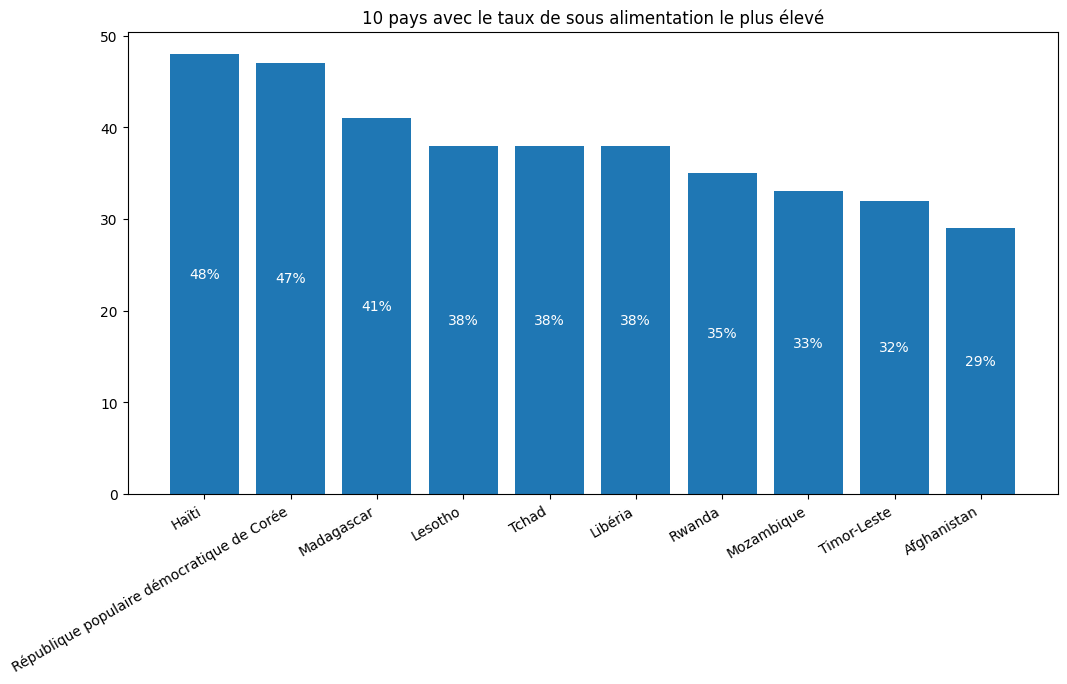

In [ ]:
#Créaton graph des 10 pires pays

plt.figure(figsize=(12,6))
# Créer les barres et les stocker
bars = plt.bar(pire_pays['Zone'], pire_pays['proportion'])
plt.xticks(rotation=30, ha='right')#permet de faire une rotation du noms des pays pour plus de lisibilité

plt.bar_label(bars, labels=[f"{v:.0f}%" for v in pire_pays['proportion']], label_type='center', color='white')
plt.title("10 pays avec le taux de sous alimentation le plus élevé")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_utilise = aide_alimentaire.copy()
aide_alimentaire_par_pays = aide_alimentaire_utilise.groupby('Zone')['Valeur'].sum().reset_index()

In [ ]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
max_aide = aide_alimentaire_par_pays.sort_values(by='Valeur', ascending=False).head(10)
max_aide

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aide_alimentaire_evolution = aide_alimentaire.copy()
aide_alimentaire_evolution = aide_alimentaire_evolution.groupby(['Zone', 'Année'])['Valeur'].sum().reset_index()
aide_alimentaire_evolution

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
cinq_pays_aide_max = max_aide["Zone"].head(5).tolist()
cinq_pays_aide_max



['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [ ]:
#On filtre sur le dataframe avec notre liste
aide_filtre = aide_alimentaire_evolution.loc[aide_alimentaire_evolution['Zone'].isin(cinq_pays_aide_max)]


In [ ]:
# Affichage des pays avec l'aide alimentaire par année
aide_filtre.pivot(index='Année', columns='Zone', values='Valeur').fillna(0)

Zone,République arabe syrienne,Soudan,Soudan du Sud,Yémen,Éthiopie
Année,,,,,
2013,563566000.0,330230000.0,196330000.0,264764000.0,591404000.0
2014,651870000.0,321904000.0,450610000.0,103840000.0,586624000.0
2015,524949000.0,17650000.0,48308000.0,372306000.0,203266000.0
2016,118558000.0,0.0,0.0,465574000.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = dispo_alimentaire.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
dispo_par_pays

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Afghanistan,2087.0
Afrique du Sud,3020.0
Albanie,3188.0
Algérie,3293.0
Allemagne,3503.0
...,...
Émirats arabes unis,3275.0
Équateur,2346.0
États-Unis d'Amérique,3682.0


,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


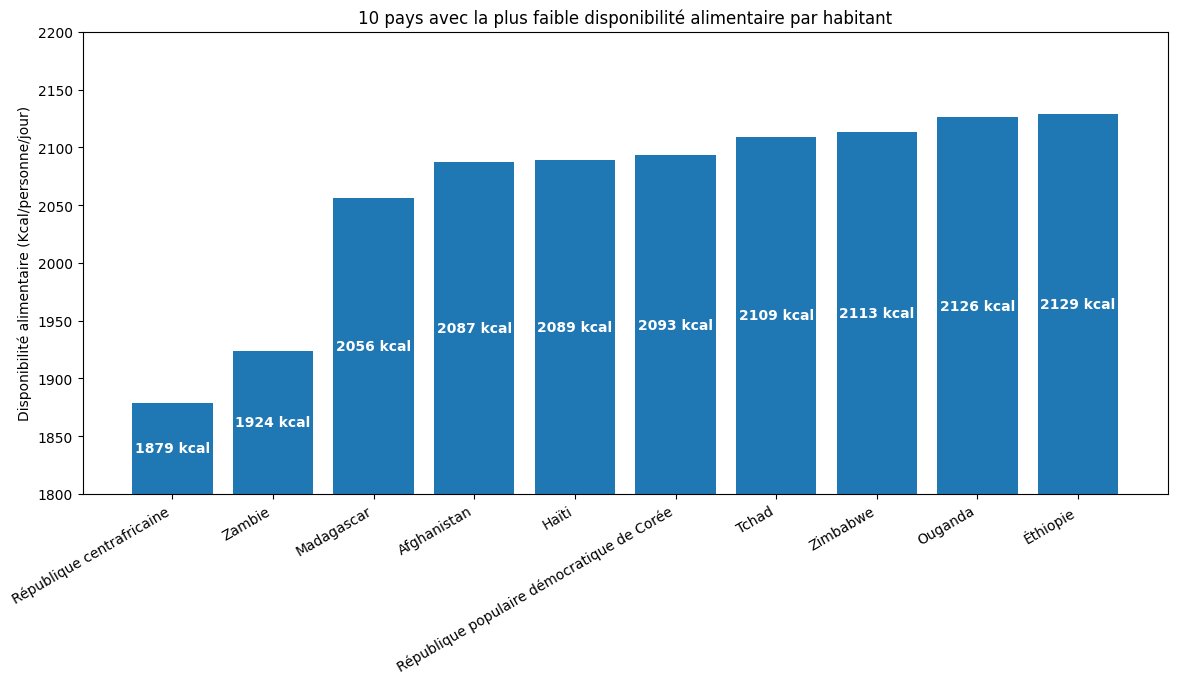

In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
display(dispo_par_pays.sort_values().head(10)) #pas besoinde ascending=True car valeur par défaut



# Création graphique
 # 1) On crée notre dataframe
dispo_par_pays_graph_bas = dispo_par_pays.sort_values().head(10).reset_index()

plt.figure(figsize=(14,6))
# 2) Créer les barres et les stocker
bars = plt.bar(dispo_par_pays_graph_bas['Zone'], dispo_par_pays_graph_bas['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xticks(rotation=30, ha='right')#permet de faire une rotation du noms des pays pour plus de lisibilité

# 3) On ajoute nos labels et titre
plt.bar_label(bars, labels=[f"{v:.0f} kcal" for v in dispo_par_pays_graph_bas['Disponibilité alimentaire (Kcal/personne/jour)']], label_type='center', color='white', weight='bold')
plt.title("10 pays avec la plus faible disponibilité alimentaire par habitant")
plt.ylim(1800,2200)
plt.ylabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

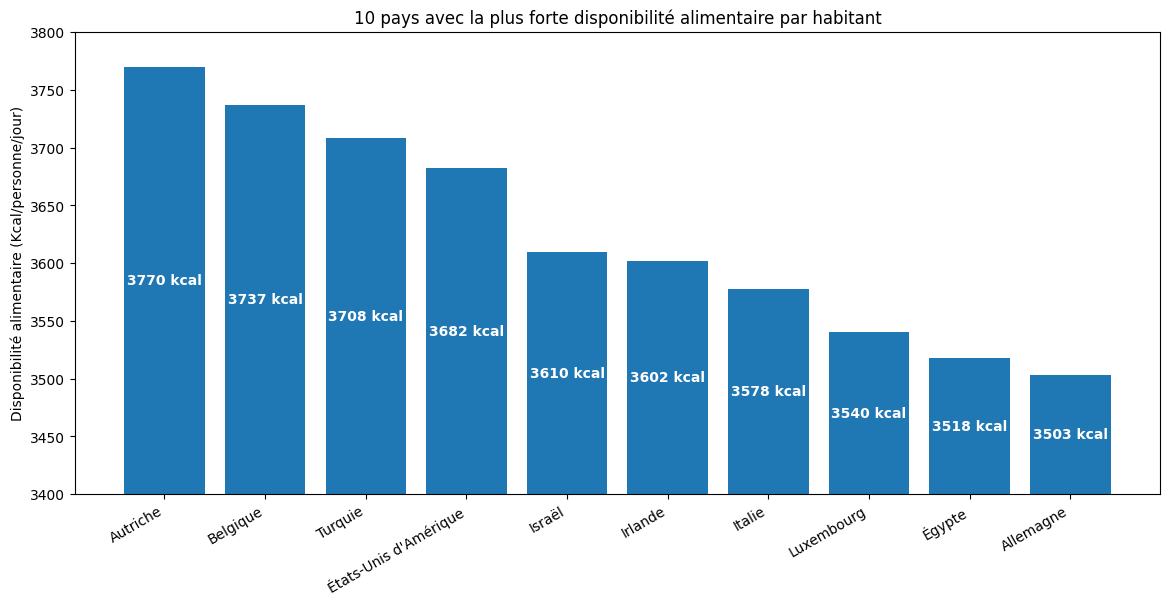

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
dispo_par_pays.sort_values(ascending=False).head(10)


# Création graphique
# 1) On crée notre dataframe
dispo_par_pays_graph_top = dispo_par_pays.sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14,6))
# 2) Créer les barres et les stocker
bars = plt.bar(x=dispo_par_pays_graph_top['Zone'], height=dispo_par_pays_graph_top['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xticks(rotation=30, ha='right')#permet de faire une rotation du noms des pays pour plus de lisibilité

# 3) On ajoute nos labels et titre
plt.bar_label(bars, labels=[f"{v:.0f} kcal" for v in dispo_par_pays_graph_top['Disponibilité alimentaire (Kcal/personne/jour)']], label_type='center', color='white', weight='bold')
plt.title("10 pays avec la plus forte disponibilité alimentaire par habitant")
plt.ylim(3400,3800)
plt.ylabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande
thailande = dispo_alimentaire.loc[dispo_alimentaire['Zone'] == 'Thaïlande']
thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,5.000000e+06,33000000.0,75000000.0,0.0,4.500000e+07,0.0,0.0,0.0
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,6.000000e+06,2000000.0,6000000.0,0.0,1.200000e+07,0.0,2000000.0,0.0
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,1.100000e+08,21000000.0,0.0,0.0,4.470000e+08,0.0,0.0,0.0
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,7.000000e+06,19000000.0,12000000.0,0.0,0.000000e+00,0.0,0.0,0.0
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,1.449000e+09,9000000.0,671000000.0,110000000.0,2.209000e+09,0.0,0.0,13000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13849,Thaïlande,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000000.0,2.200000e+07,1000000.0,871000000.0,0.0,8.910000e+08,0.0,0.0,0.0
13850,Thaïlande,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000000.0,5.360000e+08,11000000.0,917000000.0,28000000.0,1.470000e+09,0.0,0.0,0.0
13851,Thaïlande,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000000.0,9.600000e+07,4000000.0,2000000.0,0.0,0.000000e+00,0.0,0.0,0.0
13852,Thaïlande,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000000.0,8.000000e+06,16000000.0,8000000.0,0.0,0.000000e+00,0.0,0.0,0.0


In [ ]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_2017_thailande = sous_nutrition_2017[sous_nutrition_2017['Zone'] == 'Thaïlande']
display(sous_nutrition_2017_thailande)

#population totale Thailande
population_2017_thailande = population_2017[population_2017['Zone'] == 'Thaïlande']
display(population_2017_thailande)

#proportion de sous nutrition
proportion_sous_nutrition = round((sous_nutrition_2017_thailande['sous_nutrition'].sum() / population_2017_thailande['Population']).sum() * 100,0) #sum ici sert à extraire le chiffre pour faire le calcul, on pourrait aussi utiliser iloc
print(f"{proportion_sous_nutrition} % de la population est en état de sous-nutrition")

#dispo alimentaire
dispo = thailande['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
print(dispo, "kcal/jour/habitant")

,Zone,Année,sous_nutrition
1114,Thaïlande,2017,6200000.0


,Zone,Année,Population
1312,Thaïlande,2017,69209810.0


9.0 % de la population est en état de sous-nutrition
2785.0 kcal/jour/habitant


In [ ]:
# On calcule la proportion exportée en fonction de la proportion (proportion exporté de manioc j'imagine)
produit = thailande.loc[thailande['Produit'] == 'Manioc','Production'].iloc[0].astype(int)

exporte = thailande.loc[thailande['Produit'] == 'Manioc','Exportations - Quantité'].iloc[0].astype(int) # on fait cette fois avec iloc pour prendre la valeur


ratio_manioc = round((exporte / produit) * 100,0).astype(int)
print(ratio_manioc, '% du manioc produit par la Thaïlande est exporté')


83 % du manioc produit par la Thaïlande est exporté


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [ ]:
#ajouter en dessous toutes les analyses complémtaires

#calories représentées par le manioc
kcal_manioc_thailande = dispo_alimentaire_population.loc[(dispo_alimentaire_population['Zone'] == 'Thaïlande') & (dispo_alimentaire_population['Produit'] == 'Manioc'),'dispo_kcal'].sum()

#calorie représenté par le manioc exporté
nourrir_avec_manioc_exporte = round((kcal_manioc_thailande*(ratio_manioc/100)) / 2100,0)

#proportion de la population en étt de sous nutrition qui pourrait être nourrie par le manioc exporté
proportion_nourris_manioc = round((nourrir_avec_manioc_exporte / sous_nutrition_2017_thailande['sous_nutrition'].sum()) * 100,0).astype(int)
print(proportion_nourris_manioc, "% de la population thailandaise en sous nutrition pourrait être nourrie avec le manioc exporté en 2017")


18 % de la population thailandaise en sous nutrition pourrait être nourrie avec le manioc exporté en 2017


,Origine,dispo_kcal,proportion
0,animale,3.658220e+12,17.0
1,vegetale,1.726076e+13,83.0


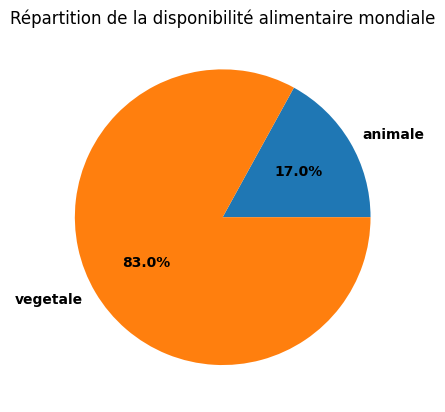

In [ ]:
# Proportion globale de la disponibilité alimentaire végétale VS animale

# 1) On regroupe par origine
kcal_par_origine_total = dispo_alimentaire_population.groupby('Origine')['dispo_kcal'].sum().reset_index()

kcal_par_origine_total["proportion"]= round((kcal_par_origine_total['dispo_kcal'] / kcal_par_origine_total['dispo_kcal'].sum()) * 100,0)
display(kcal_par_origine_total)

# 4) Crétion u graphique
plt.pie(kcal_par_origine_total["proportion"],labels=kcal_par_origine_total['Origine'],autopct="%.1f%%",  textprops={'fontweight': 'bold'})  # pourcentage avec une décimale
plt.title("Répartition de la disponibilité alimentaire mondiale")
plt.show()


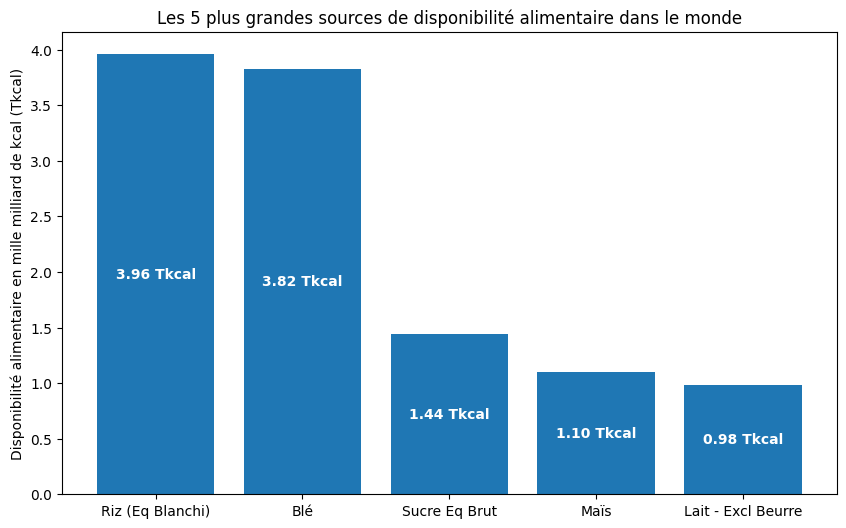

In [ ]:
# 5 plus importantes sources de calories

# 1) Crée un dataframe avec les 5 produits ayant la plus haute dispo_kcal
meilleure_dispo = dispo_alimentaire_population.groupby('Produit')['dispo_kcal'].sum().sort_values(ascending=False).head(5).reset_index()

# 2) Passe en Téra-kcal (10^12 kcal)
val_T = meilleure_dispo['dispo_kcal'] / 1e12

# 3) Créationdu graphique
plt.figure(figsize=(10,6))
bars = plt.bar(meilleure_dispo['Produit'], val_T)

plt.bar_label(bars, labels=[f"{h.get_height():.2f} Tkcal" for h in bars], label_type='center', color='white', weight='bold') #get_height() retourne la valeur de l'ordonnée ici val_T et .2f avec 2 chiffres après la virgule
plt.ylabel("Disponibilité alimentaire en mille milliard de kcal (Tkcal)")
plt.title("Les 5 plus grandes sources de disponibilité alimentaire dans le monde")
plt.show()

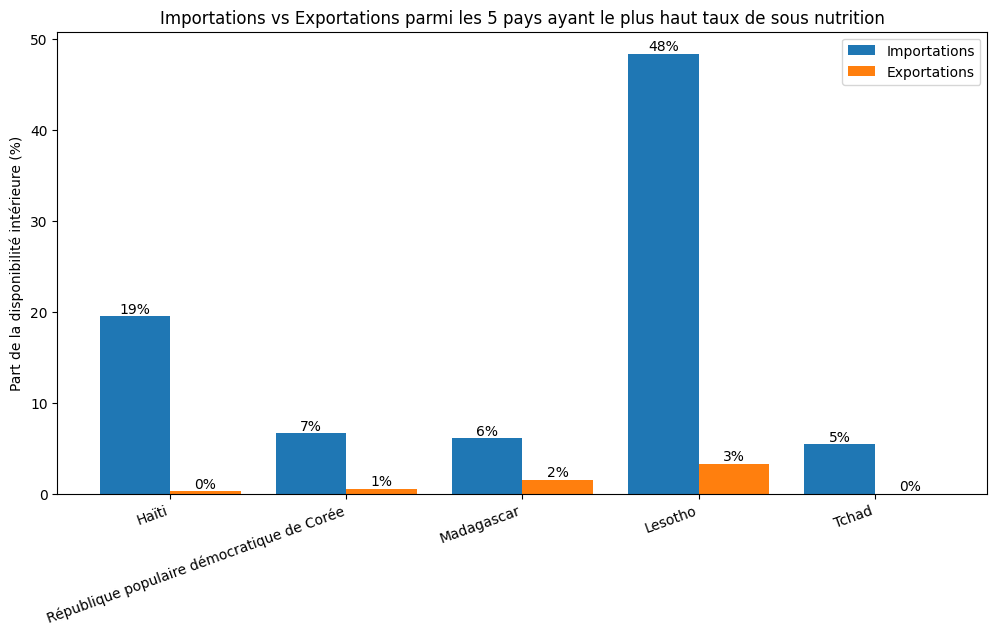

In [ ]:
# Proportion d'importations dans les 5 pays avec le plus de sous-nutrition

# Création dataframe 5 pays avec le plus haut taux de sous-nutrition
pire_cinq_pays = jointure_2017.sort_values(by='proportion', ascending=False).head(5)


# 1) Agrégation par pays sur les colonnes utiles
colonnes_utiles = ['Zone', 'Importations - Quantité', 'Exportations - Quantité', 'Disponibilité intérieure']
agregation_colonnes_utiles = (dispo_alimentaire[colonnes_utiles]
       .groupby('Zone', as_index=False).sum()) #on groupe par zone et on fait la somme de chacune des colonnes utiles on a donc pour tous les pays


# 2) Ne garder que ces 5 pays et conserver le même ordre que pire_cinq_pays
agregation_colonnes_utiles = agregation_colonnes_utiles.merge(pire_cinq_pays[['Zone','proportion']], on='Zone', how='inner')# merge inner donc on ne garde que ce qui est commun dans zone dans les deux dataframe donc les 5 pays choisis et taux de sous_nutrition
agregation_colonnes_utiles['% import'] = 100 * (agregation_colonnes_utiles['Importations - Quantité'] / agregation_colonnes_utiles['Disponibilité intérieure'])
agregation_colonnes_utiles['% export'] = 100 * (agregation_colonnes_utiles['Exportations - Quantité'] / agregation_colonnes_utiles['Disponibilité intérieure'])
agregation_colonnes_utiles = agregation_colonnes_utiles.sort_values(by='proportion', ascending=False) #pour ordonner par proportion de sous nutrition

# 3) Barres groupées
x = np.arange(len(agregation_colonnes_utiles)) # on crée une liste de la taille de notre nb de zone afin de pouvoir avoir le bon nombre d'axe et de pouvoir faire un graph a barres groupées
width = 0.4 #largeur des colonnes

plt.figure(figsize=(12,6))
bars_imp = plt.bar(x - width/2, agregation_colonnes_utiles['% import'], width, label='Importations')
bars_exp = plt.bar(x + width/2, agregation_colonnes_utiles['% export'], width, label='Exportations')

plt.xticks(x, agregation_colonnes_utiles['Zone'], rotation=20, ha='right') #on utilise le xticks afin de renommer notre axe avec le nom des zones
plt.ylabel('Part de la disponibilité intérieure (%)')
plt.title('Importations vs Exportations parmi les 5 pays ayant le plus haut taux de sous nutrition')
plt.legend()

# Étiquettes en % sur les barres, 2 boucles for car il y a deux sets de barres
for bars in (bars_imp, bars_exp):
    plt.bar_label(bars, labels=[f"{h.get_height():.0f}%" for h in bars])

plt.show()


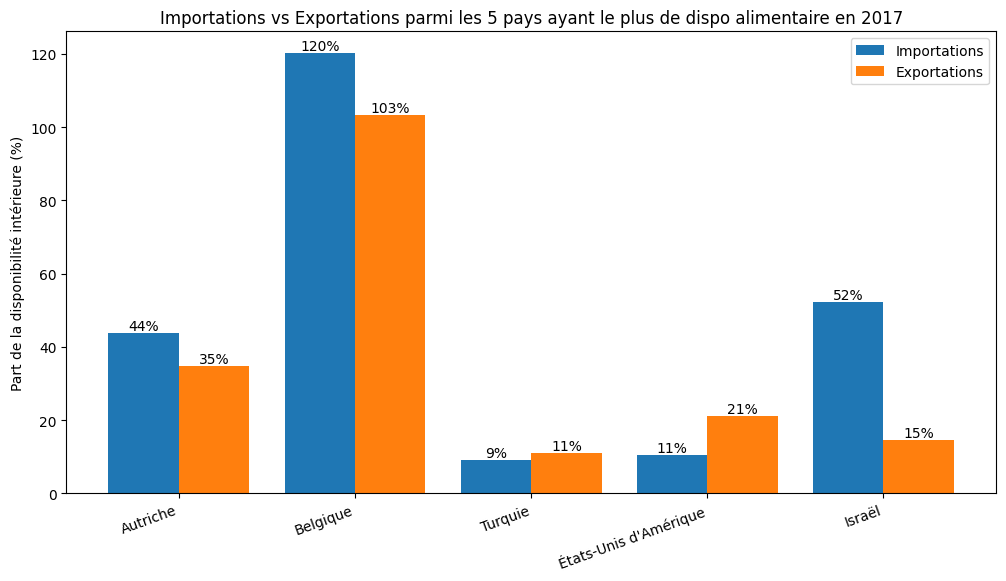

In [ ]:
# Proportion d'importations et exportations dans les 5 pays avec le plus de dispo alimentaire

#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = dispo_alimentaire.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum()

#Affichage des 5 pays qui ont le plus de dispo alimentaire par personne
dispo_par_pays_graph_haut = dispo_par_pays.sort_values(ascending=False).head(5).reset_index()

# 1) Agrégation par pays sur les colonnes utiles
colonnes_utiles = ['Zone', 'Importations - Quantité', 'Exportations - Quantité', 'Disponibilité intérieure']
agregation_colonnes_utiles = (dispo_alimentaire[colonnes_utiles]
       .groupby('Zone', as_index=False).sum()) #on groupe par zone et on fait la somme de chacune des colonnes utiles on a donc pour tous les pays


# 2) Ne garder que ces 5 pays et conserver le même ordre que pire_cinq_pays
agregation_colonnes_utiles = agregation_colonnes_utiles.merge(dispo_par_pays_graph_haut[['Zone','Disponibilité alimentaire (Kcal/personne/jour)']], on='Zone', how='inner')# merge inner donc on ne garde que ce qui est commun dans zone dans les deux dataframe donc les 5 pays choisis
agregation_colonnes_utiles['% import'] = 100 * agregation_colonnes_utiles['Importations - Quantité'] / agregation_colonnes_utiles['Disponibilité intérieure']
agregation_colonnes_utiles['% export'] = 100 * agregation_colonnes_utiles['Exportations - Quantité'] / agregation_colonnes_utiles['Disponibilité intérieure']
agregation_colonnes_utiles = agregation_colonnes_utiles.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False) #pour ordonner

# 3) Barres groupées
x = np.arange(len(agregation_colonnes_utiles)) # on crée une liste de la taille de notre nb de zone afin de pouvoir avoir le bon nombre d'axe et de pouvoir faire un graph a barres groupées
width = 0.4 #largeur des colonnes

plt.figure(figsize=(12,6))
bars_imp = plt.bar(x - width/2, agregation_colonnes_utiles['% import'], width, label='Importations')
bars_exp = plt.bar(x + width/2, agregation_colonnes_utiles['% export'], width, label='Exportations')

plt.xticks(x, agregation_colonnes_utiles['Zone'], rotation=20, ha='right') #on utilise le xticks afin de renommer notre axe avec le nom des zones
plt.ylabel('Part de la disponibilité intérieure (%)')
plt.title('Importations vs Exportations parmi les 5 pays ayant le plus de dispo alimentaire en 2017')
plt.legend()

# Étiquettes en % sur les barres
for bars in (bars_imp, bars_exp):
    plt.bar_label(bars, labels=[f"{h.get_height():.0f}%" for h in bars])

plt.show()

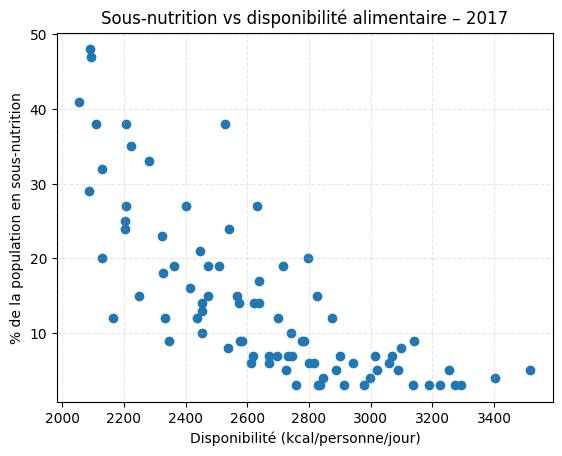

In [ ]:
#comparaison dispo alimentaire et sous nutrition

# Dataframe sous nutrition 2017
jointure_2017

# Création dataframe des 5 pays qui ont le moins de dispo alimentaire par personne
df_dispo_par_pays = dispo_par_pays.reset_index()


# fusion interne des deux dataframe
comparaison_sous_nutrition_dispo = jointure_2017.merge(df_dispo_par_pays[['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)']], on='Zone', how='inner')

# Création d'un mask
mask = ((comparaison_sous_nutrition_dispo['proportion'] > 0))

plt.scatter(comparaison_sous_nutrition_dispo.loc[mask, 'Disponibilité alimentaire (Kcal/personne/jour)'], comparaison_sous_nutrition_dispo.loc[mask, 'proportion'])

plt.title("Sous-nutrition vs disponibilité alimentaire – 2017")
plt.xlabel('Disponibilité (kcal/personne/jour)')
plt.ylabel('% de la population en sous-nutrition')
plt.grid(True, linestyle='--', alpha=0.3) #alpha augmente la transparence de la grille

plt.show()